# Showcase — the Suez Canal blockage (Ever Given, March 2021)

On **23 March 2021** the 400 m container ship *Ever Given* ran aground and wedged across the Suez Canal, halting one of the world's busiest shipping lanes for six days until it was refloated on 29 March. This notebook uses earthlens to pull the **Sentinel-2 true-colour scene** of the blockage straight from Google Earth Engine — the ship is visible lodged in the channel.

> Runs a real Earth Engine request; it degrades gracefully (prints a note) without GEE credentials.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable('earthlens')  # quieten download logs for a clean notebook

# Google Earth Engine needs a registered service account + its JSON key.
# Set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY in your environment (see the
# GEE Authentication docs); the placeholders keep this notebook importable.
SERVICE_ACCOUNT = os.environ.get(
    'GEE_SERVICE_ACCOUNT', 'my-sa@my-project.iam.gserviceaccount.com'
)
SERVICE_KEY = os.environ.get('GEE_SERVICE_KEY', '/path/to/key.json')

def true_colour(path, pct=(2, 98)):
    """Read a 3-band GeoTIFF and percentile-stretch it to an RGB array."""
    arr = np.asarray(Dataset.read_file(str(path)).read_array(), dtype='float32')
    def stretch(band):
        lo, hi = np.nanpercentile(band, pct[0]), np.nanpercentile(band, pct[1])
        return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return np.dstack([stretch(arr[i]) for i in range(3)])


2026-06-07 19:25:29 | INFO | pyramids.base.config | Logging is configured.


## Fetch the scene

A tight bbox over the grounding site (~30.02°N, 32.58°E), the bands `B4`/`B3`/`B2` (red/green/blue), and `temporal_resolution='raw'` so the whole grounding window collapses to a single median composite. Earth Engine clips server-side, so only a small GeoTIFF crosses the wire.

In [2]:
out = tempfile.mkdtemp(prefix='suez_')
suez = EarthLens(
    data_source='gee',
    start='2021-03-24', end='2021-03-27',          # Ever Given aground 23-29 Mar
    temporal_resolution='raw',                      # one composite over the window
    variables={'COPERNICUS/S2_SR_HARMONIZED': ['B4', 'B3', 'B2']},
    lat_lim=[30.005, 30.030], lon_lim=[32.570, 32.592],
    path=out, scale=10, reducer='median',
    service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY,
)
try:
    paths = suez.download(progress_bar=False)
except Exception as exc:  # noqa: BLE001 - stays runnable without GEE creds
    paths = []
    print('download skipped (needs GEE credentials):', exc)
print(f'{len(paths)} scene written')

1 scene written


## Show the blockage

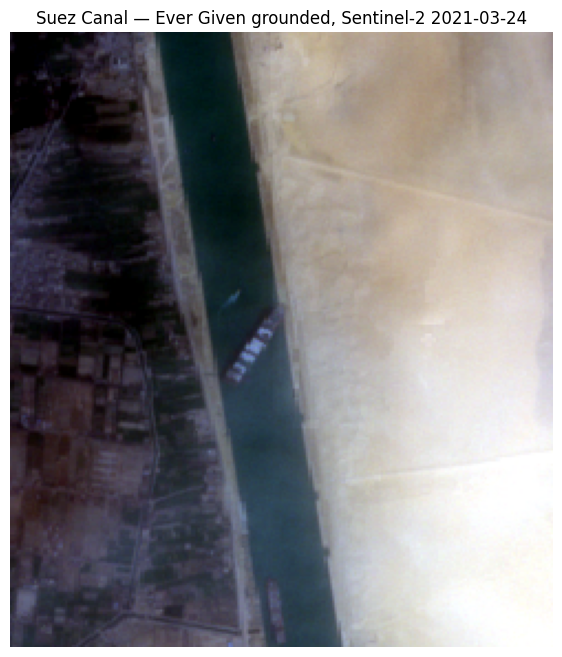

In [3]:
if paths:
    plt.figure(figsize=(7, 8))
    plt.imshow(true_colour(paths[0]))
    plt.title('Suez Canal — Ever Given grounded, Sentinel-2 2021-03-24')
    plt.axis('off'); plt.show()
else:
    print('no scene written — set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun')